<a href="https://colab.research.google.com/github/lipakshipanda/cse_aiml_labwork/blob/main/ml_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**lab1**
 Data cleaning:  Filling in missing values, cleaning and filling missing data, drop
missing values, smoothing noisy data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Load a sample dataset with missing values

data = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [25, np.nan, 23, 24, np.nan],
    'Marks': [85, 78, np.nan, 92, 88]
})

print("Original Dataset:\n", data)



Original Dataset:
       Name   Age  Marks
0    Alice  25.0   85.0
1      Bob   NaN   78.0
2  Charlie  23.0    NaN
3    David  24.0   92.0
4      Eva   NaN   88.0


In [ ]:
# 1. Detect missing data

print("\nMissing Value Summary:\n", data.isnull().sum())





Missing Value Summary:
 Name     0
Age      2
Marks    1
dtype: int64


In [ ]:
# 2. Drop missing values
data_dropped = data.dropna()
print("\nAfter Dropping Missing Values:\n", data_dropped)




After Dropping Missing Values:
     Name   Age  Marks
0  Alice  25.0   85.0
3  David  24.0   92.0


In [ ]:
# 3. Fill missing values with Mean

data_filled_mean = data.copy()
data_filled_mean['Age'].fillna(data['Age'].mean(), inplace=True)
data_filled_mean['Marks'].fillna(data['Marks'].mean(), inplace=True)
print("\nAfter Filling with Mean:\n", data_filled_mean)




After Filling with Mean:
       Name   Age  Marks
0    Alice  25.0  85.00
1      Bob  24.0  78.00
2  Charlie  23.0  85.75
3    David  24.0  92.00
4      Eva  24.0  88.00


/tmp/ipython-input-2257677607.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_filled_mean['Age'].fillna(data['Age'].mean(), inplace=True)
/tmp/ipython-input-2257677607.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:

# 4. Fill with Forward Fill

data_ffill = data.fillna(method='ffill')
print("\nAfter Forward Fill:\n", data_ffill)




After Forward Fill:
       Name   Age  Marks
0    Alice  25.0   85.0
1      Bob  25.0   78.0
2  Charlie  23.0   78.0
3    David  24.0   92.0
4      Eva  24.0   88.0


/tmp/ipython-input-2534407853.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_ffill = data.fillna(method='ffill')


In [ ]:

# 5. Fill with Backward Fill

data_bfill = data.fillna(method='bfill')
print("\nAfter Backward Fill:\n", data_bfill)




After Backward Fill:
       Name   Age  Marks
0    Alice  25.0   85.0
1      Bob  23.0   78.0
2  Charlie  23.0   92.0
3    David  24.0   92.0
4      Eva   NaN   88.0


/tmp/ipython-input-2956079671.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_bfill = data.fillna(method='bfill')


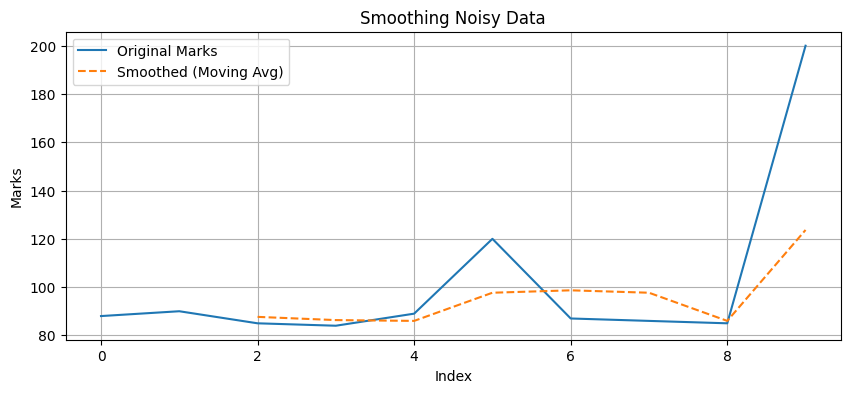

In [ ]:
# 6. Smoothing Noisy Data with Moving Average
# Simulated noisy marks data
marks = [88, 90, 85, 84, 89, 120, 87, 86, 85, 200]  # contains noise
marks_series = pd.Series(marks)

smoothed = marks_series.rolling(window=3).mean()

# Plotting before and after smoothing
plt.figure(figsize=(10, 4))
plt.plot(marks, label='Original Marks')
plt.plot(smoothed, label='Smoothed (Moving Avg)', linestyle='--')
plt.title("Smoothing Noisy Data")
plt.xlabel("Index")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

#**lab2**
 Dimensionality reduction using PCA

In [ ]:
import numpy as np

def pca(data: np.ndarray):

    if data.shape[0] < data.shape[1]:
        data = data.T


    means = np.mean(data, axis=0)
    mean_centered = data - means


    cov_matrix = np.cov(mean_centered, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    pc1_vector = eigenvectors[:, 0] / np.linalg.norm(eigenvectors[:, 0])

    proj_1d = mean_centered @ pc1_vector

    var_explained = (eigenvalues[0] / np.sum(eigenvalues)) * 100

    return {
        "means": means,
        "X_centered": mean_centered,
        "cov_matrix": cov_matrix,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "pc1_vector": pc1_vector,
        "proj_1d": proj_1d,
        "var_explained": var_explained
    }

In [ ]:
data = np.array([
    [0.7, 0.81, 0.76, 0.82],
    [0.9, 0.73, 0.94, 0.71]
])

results = pca(data)

for key, value in results.items():
    print(f"{key}:\n{value}\n")

means:
[0.7725 0.82  ]

X_centered:
[[-0.0725  0.08  ]
 [ 0.0375 -0.09  ]
 [-0.0125  0.12  ]
 [ 0.0475 -0.11  ]]

cov_matrix:
[[ 0.003025   -0.0053    ]
 [-0.0053      0.01366667]]

eigenvalues:
[0.01585591 0.00083576]

eigenvectors:
[[ 0.38177713 -0.92425441]
 [-0.92425441 -0.38177713]]

pc1_vector:
[ 0.38177713 -0.92425441]

proj_1d:
[-0.1016192   0.09749954 -0.11568274  0.1198024 ]

var_explained:
94.99297685498543



#**lab3**
Build a decision tree classifier on a dataset

Weather    Time Discount Member Buy Coffee
  Sunny Morning      Yes    Yes        Yes
  Sunny Morning       No    Yes        Yes
  Sunny Evening       No    Yes         No
  Sunny Evening      Yes     No        Yes
  Rainy Morning      Yes    Yes        Yes
  Rainy Morning       No     No         No
  Rainy Evening      Yes     No        Yes
  Rainy Evening       No     No         No
  Sunny Morning      Yes     No        Yes
  Sunny Evening       No     No         No
  Rainy Morning      Yes     No        Yes
  Rainy Morning       No     No         No
  Sunny Morning      Yes     No        Yes
  Rainy Evening       No    Yes         No

------------------------------------------------------------
Depth 0  — Node: split on feature = 'Discount'
H(parent) = 0.985228
IGs (feature : IG
  - Discount   : IG = 0.689392
  - Time       : IG = 0.128085
  - Weather    : IG = 0.061054
  - Member     : IG = 0.001340

Child splits for chosen feature:
  * Yes      : n= 7, Yes=7, No=0
  * No       : n

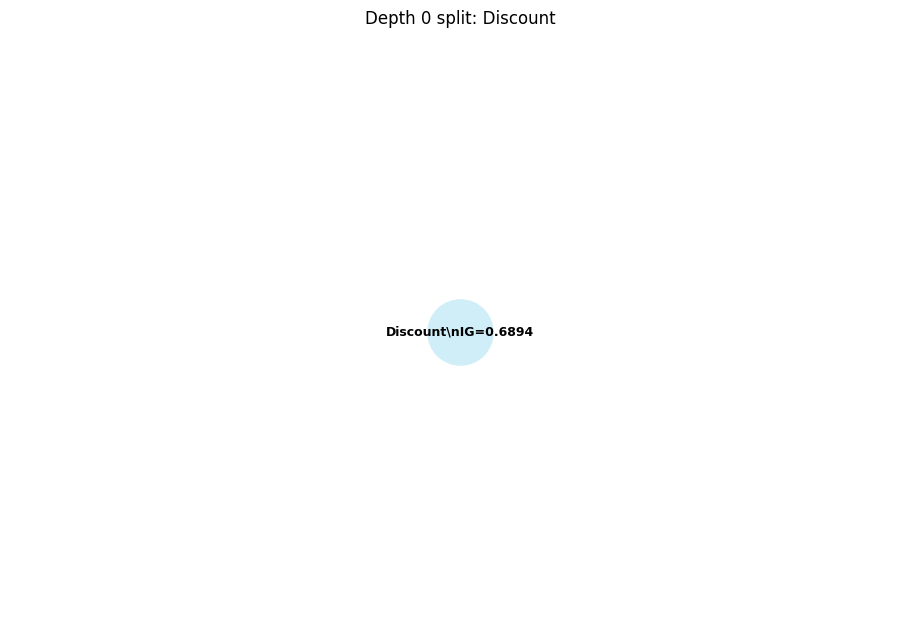


------------------------------------------------------------
Depth 1  — Node: split on feature = 'Weather'
H(parent) = 0.591673
IGs (feature : IG
  - Weather    : IG = 0.198117
  - Time       : IG = 0.198117
  - Member     : IG = 0.198117

Child splits for chosen feature:
  * Sunny    : n= 3, Yes=1, No=2
  * Rainy    : n= 4, Yes=0, No=4


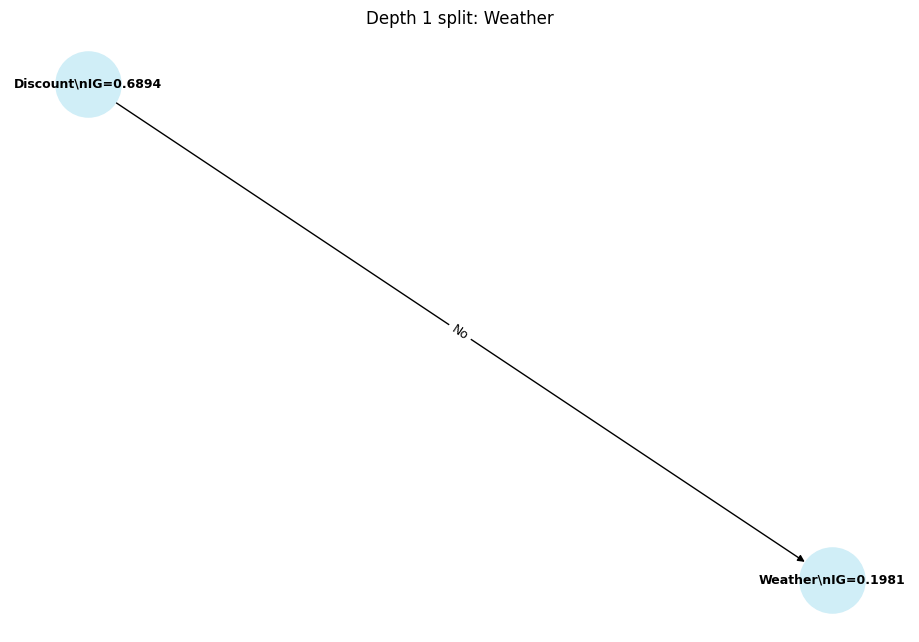


------------------------------------------------------------
Depth 2  — Node: split on feature = 'Time'
H(parent) = 0.918296
IGs (feature : IG
  - Time       : IG = 0.918296
  - Member     : IG = 0.251629

Child splits for chosen feature:
  * Morning  : n= 1, Yes=1, No=0
  * Evening  : n= 2, Yes=0, No=2


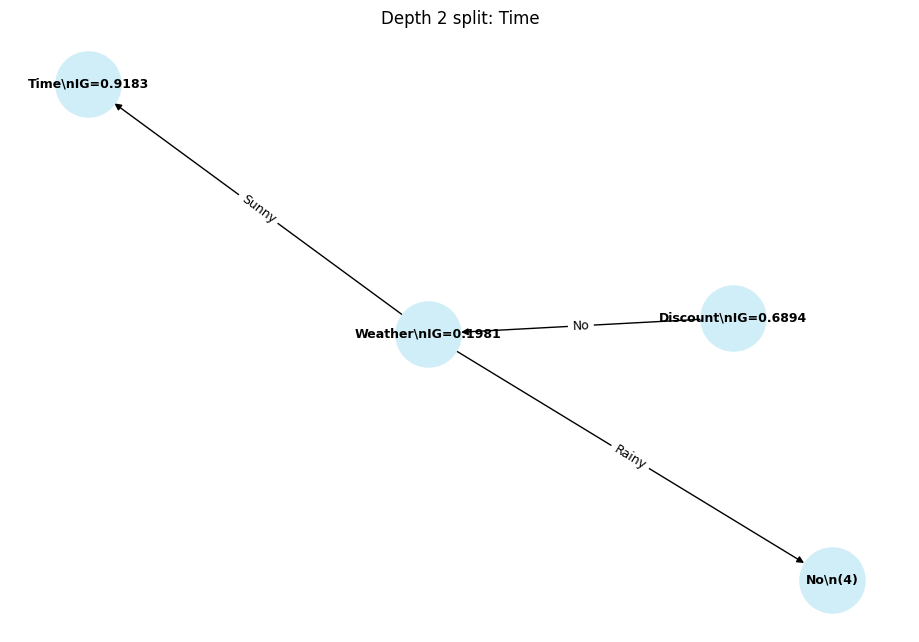

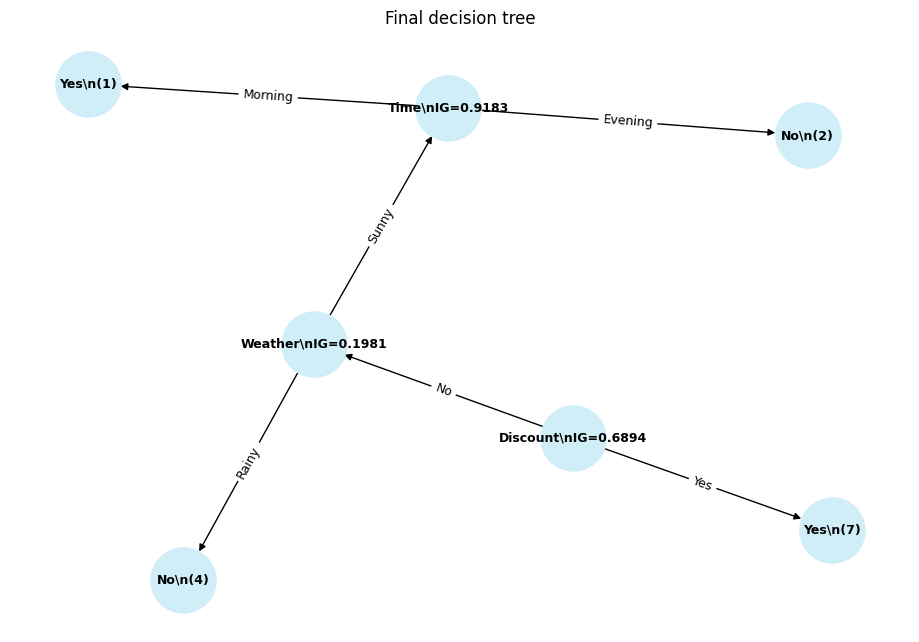

In [ ]:
import pandas as pd
import numpy as np
import math
from collections import Counter, defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import os, shutil


dataset = [
    ("Sunny","Morning","Yes","Yes","Yes"),
    ("Sunny","Morning","No","Yes","Yes"),
    ("Sunny","Evening","No","Yes","No"),
    ("Sunny","Evening","Yes","No","Yes"),
    ("Rainy","Morning","Yes","Yes","Yes"),
    ("Rainy","Morning","No","No","No"),
    ("Rainy","Evening","Yes","No","Yes"),
    ("Rainy","Evening","No","No","No"),
    ("Sunny","Morning","Yes","No","Yes"),
    ("Sunny","Evening","No","No","No"),
    ("Rainy","Morning","Yes","No","Yes"),
    ("Rainy","Morning","No","No","No"),
    ("Sunny","Morning","Yes","No","Yes"),
    ("Rainy","Evening","No","Yes","No")
]
df = pd.DataFrame(dataset, columns=["Weather","Time","Discount","Member","Buy Coffee"])

print(df.to_string(index=False))


def entropy_series(s):
    counts = s.value_counts()
    total = counts.sum()
    ent = 0.0
    for c in counts:
        p = c/total
        if p > 0:
            ent -= p * math.log2(p)
    return ent

def info_gain_df(df, feature, target):
    H_parent = entropy_series(df[target])
    total = len(df)
    cond = 0.0
    splits = []

    cats = list(dict.fromkeys(df[feature].tolist()))
    for val in cats:
        subset = df[df[feature] == val]
        w = len(subset) / total
        H_child = entropy_series(subset[target])
        cond += w * H_child
        counts = subset[target].value_counts().to_dict()
        splits.append({"value": val, "n": len(subset), "counts": counts, "entropy": H_child, "weight": w, "w_entropy": w*H_child})
    IG = H_parent - cond
    return {"feature": feature, "H_parent": H_parent, "cond_entropy": cond, "IG": IG, "splits": splits}


node_counter = 0
nodes = {}
edges = []

def new_node(label, is_leaf=False, pred=None, samples=None):
    global node_counter, nodes
    node_counter += 1
    nodes[node_counter] = {"id": node_counter, "label": label, "is_leaf": is_leaf, "pred": pred, "samples": samples, "children": {}}
    return node_counter

def add_edge(parent, child, branch_label):
    edges.append((parent, child, branch_label))
    nodes[parent]["children"][branch_label] = child

def draw_current_tree(title, save_as=None):
    G = nx.DiGraph()
    for nid in nodes:
        G.add_node(nid)
    for u,v,lab in edges:
        G.add_edge(u, v)
    labels = {}
    for nid, nd in nodes.items():
        if nd["is_leaf"]:
            labels[nid] = f"{nd['pred']}\\n({nd['samples']})"
        else:
            labels[nid] = nd["label"]
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(9,6))
    nx.draw(G, pos, labels=labels, node_size=2200, node_color="#d0eef7", font_size=9, font_weight="bold")
    edge_labels = {(u,v): lab for u,v,lab in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title(title)
    plt.axis("off")
    if save_as:
        plt.savefig(save_as, bbox_inches="tight")
    plt.show()
    plt.close()


snapshots = []

def build_id3(df_subset, features, target, parent=None, branch_label=None, depth=0):


    value_counts = df_subset[target].value_counts().to_dict()
    if len(value_counts) == 1:
        pred = next(iter(value_counts.keys()))
        leaf_id = new_node(label=f"Leaf:{pred}", is_leaf=True, pred=pred, samples=len(df_subset))
        if parent:
            add_edge(parent, leaf_id, branch_label)
        return leaf_id

    if not features:

        pred = df_subset[target].mode()[0]
        leaf_id = new_node(label=f"Leaf:{pred}", is_leaf=True, pred=pred, samples=len(df_subset))
        if parent:
            add_edge(parent, leaf_id, branch_label)
        return leaf_id


    candidate_infos = [info_gain_df(df_subset, f, target) for f in features]
    candidate_infos.sort(key=lambda x: x["IG"], reverse=True)
    best = candidate_infos[0]
    best_feature = best["feature"]

    node_label = f"{best_feature}\\nIG={best['IG']:.4f}"
    node_id = new_node(label=node_label, is_leaf=False, samples=len(df_subset))
    if parent:
        add_edge(parent, node_id, branch_label)


    print("\n" + "-"*60)
    print(f"Depth {depth}  — Node: split on feature = '{best_feature}'")
    print(f"H(parent) = {best['H_parent']:.6f}")
    print("IGs (feature : IG")
    for info in candidate_infos:
        print(f"  - {info['feature']:10s} : IG = {info['IG']:.6f}")
    print("\nChild splits for chosen feature:")
    for s in best["splits"]:
        yes = s["counts"].get("Yes", 0)
        no  = s["counts"].get("No", 0)
        print(f"  * {s['value']:8s} : n={s['n']:2d}, Yes={yes}, No={no}")

    draw_current_tree(title=f"Depth {depth} split: {best_feature}")

    remaining = [f for f in features if f != best_feature]
    for val, subset in df_subset.groupby(best_feature):
        build_id3(subset, remaining, target, parent=node_id, branch_label=val, depth=depth+1)

    return node_id



OUTDIR = "tree_steps"
if os.path.exists(OUTDIR):
    shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

root_id = build_id3(df, ["Weather","Time","Discount","Member"], "Buy Coffee")


final_filename = os.path.join(OUTDIR, "final_tree")
draw_current_tree("Final decision tree", save_as=final_filename)


#**lab4**
implementation of Perceptron learning for binary classification.

In [ ]:
from tabulate import tabulate


data = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
]


w0, w1, w2 = 0.7, 0.9, 0.71
eta = 0.5


def activation(y_in):
    return 1 if y_in >= 0 else 0

iteration = 0
converged = False

while not converged:
    iteration += 1
    results = []
    weight_changed = False

    print(f"\nIteration {iteration}")

    for x1, x2, target in data:
        # Net input
        net = w0*1 + w1*x1 + w2*x2

        # Output
        theta = activation(net)

        # Error
        error = target - theta


        dw0 = eta * error * 1
        dw1 = eta * error * x1
        dw2 = eta * error * x2

        # Save row
        results.append([
            x1, x2,
            round(w0,4), round(w1,4), round(w2,4),
            round(net,4), theta, target, error,
            round(dw0,4), round(dw1,4), round(dw2,4)
        ])

        # Update weights
        if dw0 != 0 or dw1 != 0 or dw2 != 0:
            weight_changed = True
        w0 += dw0
        w1 += dw1
        w2 += dw2

    # Define column headers
    columns = ["x1", "x2", "w0", "w1", "w2", "sum", "theta", "target", "dw0", "dw1", "dw2"]

    # Print clean table
    print(tabulate(results, headers=columns, tablefmt="grid"))

    # Print weights after this iteration
    print(f"\nUpdated Weights after Iteration {iteration}: w0 = {round(w0,4)}, w1 = {round(w1,4)}, w2 = {round(w2,4)}")

    # Check for convergence
    if not weight_changed:
        converged = True
        print(f"\nPerceptron converged after {iteration} iterations!")



=========== Iteration 1 ===========
+------+------+------+------+------+-------+---------+----------+---------+-------+-------+-------+
|   x1 |   x2 |   w0 |   w1 |   w2 |   net |   theta |   target |   error |   dw0 |   dw1 |   dw2 |
+======+======+======+======+======+=======+=========+==========+=========+=======+=======+=======+
|    0 |    0 | 1.12 | 1.15 | 1.25 |  1.12 |       1 |        0 |      -1 |  -0.5 |    -0 |    -0 |
+------+------+------+------+------+-------+---------+----------+---------+-------+-------+-------+
|    0 |    1 | 0.62 | 1.15 | 1.25 |  1.87 |       1 |        1 |       0 |   0   |     0 |     0 |
+------+------+------+------+------+-------+---------+----------+---------+-------+-------+-------+
|    1 |    0 | 0.62 | 1.15 | 1.25 |  1.77 |       1 |        1 |       0 |   0   |     0 |     0 |
+------+------+------+------+------+-------+---------+----------+---------+-------+-------+-------+
|    1 |    1 | 0.62 | 1.15 | 1.25 |  3.02 |       1 |        1

#**lab5**
 Implementation of ANN with back propagation for binary classification.

In [ ]:
import numpy as np

# Define the Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# The derivative of the sigmoid function is needed for backpropagation
def sigmoid_derivative(x):
    return x * (1 - x)

# --- Initial Parameters from the PDF ---
inputs = np.array([[0.7, 0.9]])
targets = np.array([[0.9, 0.7]])
learning_rate = 0.5

# --- Network Architecture ---
# Weights from Input to Hidden Layer
weights_ih = np.array([[0.71, 0.81], [0.74, 0.84]])
# Weights from Hidden to Output Layer
weights_ho = np.array([[0.72, 0.82], [0.85, 0.95]])
# Biases
bias_h = 0.96
bias_o = 0.77

# --- Training Process for 2 Iterations ---
for i in range(2):
    print(f"--- ITERATION {i+1} ---")

    # --- 1. FORWARD PASS ---
    # Calculate net input to the hidden layer
    hidden_layer_input = np.dot(inputs, weights_ih) + bias_h
    # Calculate the output of the hidden layer
    hidden_layer_output = sigmoid(hidden_layer_input)

    # Calculate net input to the output layer
    output_layer_input = np.dot(hidden_layer_output, weights_ho) + bias_o
    # Calculate the final predicted output
    predicted_output = sigmoid(output_layer_input)

    print("Forward Pass Results:")
    # Print the total input for each hidden layer neuron
    print(f"  Net Input to Hidden Layer (net_h1, net_h2): {hidden_layer_input}") # <-- ADDED
    print(f"  Hidden Layer Output (out_h1, out_h2): {hidden_layer_output}")
    # Print the total input for each output layer neuron
    print(f"  Net Input to Output Layer (net_o1, net_o2): {output_layer_input}") # <-- ADDED
    print(f"  Predicted Output (out_o1, out_o2): {predicted_output}\n")

    # --- 2. BACKWARD PASS ---
    error = targets - predicted_output

    # Calculate the individual error for each output, as shown in the PDF
    individual_errors = 0.5 * (error ** 2) # <-- ADDED

    d_predicted_output = error * sigmoid_derivative(predicted_output)
    error_hidden_layer = d_predicted_output.dot(weights_ho.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    # --- 3. UPDATE WEIGHTS ---
    weights_ho += hidden_layer_output.T.dot(d_predicted_output) * learning_rate
    weights_ih += inputs.T.dot(d_hidden_layer) * learning_rate

    print("Backward Pass & Error Calculation:")
    # Print the individual error values
    print(f"  Individual Error (E_o1, E_o2): {individual_errors}\n") # <-- ADDED
    print("Updated Weights:")
    print(f"  Input -> Hidden: \n{weights_ih}")
    print(f"  Hidden -> Output: \n{weights_ho}")
    print("-" * 35 + "\n")

--- ITERATION 1 ---
Forward Pass Results:
  Net Input to Hidden Layer (net_h1, net_h2): [[2.123 2.283]]
  Hidden Layer Output (out_h1, out_h2): [[0.89311864 0.90745929]]
  Net Input to Output Layer (net_o1, net_o2): [[2.18438581 2.36444361]]
  Predicted Output (out_o1, out_o2): [[0.89883856 0.91407546]]

Backward Pass & Error Calculation:
  Individual Error (E_o1, E_o2): [[6.74468296e-07 2.29141504e-02]]

Updated Weights:
  Input -> Hidden: 
[[0.7095419  0.80953316]
 [0.73941102 0.83939977]]
  Hidden -> Output: 
[[0.72004716 0.81249164]
 [0.85004792 0.94237108]]
-----------------------------------

--- ITERATION 2 ---
Forward Pass Results:
  Net Input to Hidden Layer (net_h1, net_h2): [[2.12214925 2.28213301]]
  Hidden Layer Output (out_h1, out_h2): [[0.8930374  0.90738645]]
  Net Input to Output Layer (net_o1, net_o2): [[2.18435101 2.35068017]]
  Predicted Output (out_o1, out_o2): [[0.8988354  0.91298828]]

Backward Pass & Error Calculation:
  Individual Error (E_o1, E_o2): [[6.781489

#**lab6**
 Performance evaluation of SVM for multi-class classification.

Accuracy: 0.7167
              precision    recall  f1-score   support

           0       0.58      0.60      0.59        30
           1       0.79      0.77      0.78        30
           2       0.75      0.70      0.72        30
           3       0.75      0.80      0.77        30

    accuracy                           0.72       120
   macro avg       0.72      0.72      0.72       120
weighted avg       0.72      0.72      0.72       120



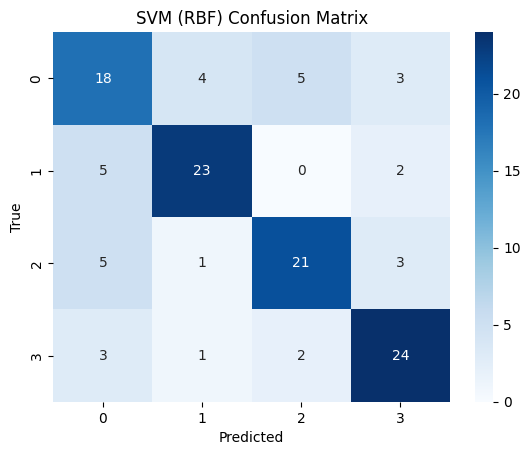

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X, y = make_classification(n_samples=600, n_features=10, n_informative=6,
                           n_redundant=2, n_classes=4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('SVM (RBF) Confusion Matrix')
plt.show()

#**lab7**
 Implement Bayes theorem.

In [ ]:
p_s = 0.04
p_not_s = 1 - p_s
p_pos_given_s = 0.90
p_pos_given_not_s = 0.08
print("Initial Probabilities")
print(f"P(Structure)=[P(S)]: {p_s}")
print(f"P(No Structure)=[P(~S)]: {p_not_s:.2f}")
print(f"P(Positive Alert | Structure)=[P(+/S)]: {p_pos_given_s}")
print(f"P(Positive Alert | No Structure)=[P(+/~S)]: {p_pos_given_not_s}")
print("Positive Test Analysis: P(S|+)")
p_pos_and_s = p_pos_given_s * p_s
p_pos_and_not_s = p_pos_given_not_s * p_not_s
p_pos = p_pos_and_s + p_pos_and_not_s
p_s_given_pos = p_pos_and_s / p_pos
print(f"P(+/S) * P(S) = {p_pos_given_s} * {p_s} = {p_pos_and_s:.4f}")
print(f"P(+/~S) * P(~S) = {p_pos_given_not_s} * {p_not_s:.2f} = {p_pos_and_not_s:.4f}")
print(f"P(+) = {p_pos_and_s:.4f} + {p_pos_and_not_s:.4f} = {p_pos:.4f}")
print(f"P(S|+) = {p_pos_and_s:.4f} / {p_pos:.4f} = {p_s_given_pos:.4f}")
print(f"\nFinal Answer (Positive): {p_s_given_pos:.2%}")
print("\nNegative Test Analysis: P(S|-) ")
p_neg_given_s = 1 - p_pos_given_s
p_neg_given_not_s = 1 - p_pos_given_not_s
print(f"P(-|S) = 1 - P(+/S) = 1 - {p_pos_given_s} = {p_neg_given_s:.2f}")
print(f"P(-|~S) = 1 - P(+/~S) = 1 - {p_pos_given_not_s} = {p_neg_given_not_s:.2f}")
p_neg_and_s = p_neg_given_s * p_s
p_neg_and_not_s = p_neg_given_not_s * p_not_s
p_neg = p_neg_and_s + p_neg_and_not_s
print(f"P(-) = ({p_neg_and_s:.4f}) + ({p_neg_and_not_s:.4f}) = {p_neg:.4f}")
p_s_given_neg = p_neg_and_s / p_neg
print(f"P(S|-) = {p_neg_and_s:.4f} / {p_neg:.4f} = {p_s_given_neg:.4f}")
print(f"\nFinal Answer (Negative): {p_s_given_neg:.2%}")

Initial Probabilities
P(Structure)=[P(S)]: 0.04
P(No Structure)=[P(~S)]: 0.96
P(Positive Alert | Structure)=[P(+/S)]: 0.9
P(Positive Alert | No Structure)=[P(+/~S)]: 0.08
Positive Test Analysis: P(S|+)
P(+/S) * P(S) = 0.9 * 0.04 = 0.0360
P(+/~S) * P(~S) = 0.08 * 0.96 = 0.0768
P(+) = 0.0360 + 0.0768 = 0.1128
P(S|+) = 0.0360 / 0.1128 = 0.3191

Final Answer (Positive): 31.91%

Negative Test Analysis: P(S|-) 
P(-|S) = 1 - P(+/S) = 1 - 0.9 = 0.10
P(-|~S) = 1 - P(+/~S) = 1 - 0.08 = 0.92
P(-) = (0.0040) + (0.8832) = 0.8872
P(S|-) = 0.0040 / 0.8872 = 0.0045

Final Answer (Negative): 0.45%


# **lab8**
Implement a Naive Bayes classifier for text classification.

In [ ]:
import pandas as pd
data = {
    'Scholarship': ['Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes'],
    'Campus Visit': ['Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes'],
    'Distance': ['Far', 'Near', 'Far', 'Near', 'Far', 'Near', 'Near', 'Far', 'Near', 'Far'],
    'Legacy': ['No', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes'],
    'Enrolled': ['Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)
new_applicant = {
    'Scholarship': 'Yes',
    'Campus Visit': 'No',
    'Distance': 'Near',
    'Legacy': 'No'
}
df_yes = df[df['Enrolled'] == 'Yes']
df_no = df[df['Enrolled'] == 'No']
total_count = len(df)
yes_count = len(df_yes)
no_count = len(df_no)
prob_yes = yes_count / total_count
prob_no = no_count / total_count
print(f"Total Records: {total_count}")
print(f"Count(Yes): {yes_count}")
print(f"Count(No): {no_count}")
print(f"P(Yes) = {yes_count}/{total_count}")
print(f"P(No) = {no_count}/{total_count}")
print("Calculating Likelihood(Yes)")
likelihood_yes = prob_yes
print(f"  Starting with P(Yes) = {prob_yes:.4f}")
for feature, value in new_applicant.items():
    feature_count_yes = (df_yes[feature] == value).sum()
    cond_prob_yes = feature_count_yes / yes_count
    print(f"  * P({feature}='{value}' | Yes) = {feature_count_yes}/{yes_count} = {cond_prob_yes:.4f}")
    likelihood_yes *= cond_prob_yes
print(f"\n  Final Likelihood(Yes) ∝ {likelihood_yes:.6f}")
print("Calculating Likelihood(No)")
likelihood_no = prob_no
print(f"  Starting with P(No) = {prob_no:.4f}")
for feature, value in new_applicant.items():
    feature_count_no = (df_no[feature] == value).sum()
    cond_prob_no = feature_count_no / no_count
    print(f"  * P({feature}='{value}' | No) = {feature_count_no}/{no_count} = {cond_prob_no:.4f}")
    likelihood_no *= cond_prob_no
print(f"\n  Final Likelihood(No) ∝ {likelihood_no:.6f}")
print(f"Likelihood(Yes) ∝ {likelihood_yes:.6f}")
print(f"Likelihood(No) ∝ {likelihood_no:.6f}")
if likelihood_yes > likelihood_no:
    print("\n Prediction: The student will ENROLL.")
else:
    print("\n Prediction: The student will NOT ENROLL.")

Total Records: 10
Count(Yes): 6
Count(No): 4
P(Yes) = 6/10
P(No) = 4/10
Calculating Likelihood(Yes)
  Starting with P(Yes) = 0.6000
  * P(Scholarship='Yes' | Yes) = 4/6 = 0.6667
  * P(Campus Visit='No' | Yes) = 1/6 = 0.1667
  * P(Distance='Near' | Yes) = 3/6 = 0.5000
  * P(Legacy='No' | Yes) = 3/6 = 0.5000

  Final Likelihood(Yes) ∝ 0.016667
Calculating Likelihood(No)
  Starting with P(No) = 0.4000
  * P(Scholarship='Yes' | No) = 1/4 = 0.2500
  * P(Campus Visit='No' | No) = 4/4 = 1.0000
  * P(Distance='Near' | No) = 2/4 = 0.5000
  * P(Legacy='No' | No) = 3/4 = 0.7500

  Final Likelihood(No) ∝ 0.037500
Likelihood(Yes) ∝ 0.016667
Likelihood(No) ∝ 0.037500

 Prediction: The student will NOT ENROLL.


# **lab9**
 Statistical relation between two variables and scatter plots using linear regression.

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Data Input (The final, verified values)
X = np.array([65, 70, 55, 75, 80, 60, 50, 85, 70, 60]) # Humidity (%)
Y = np.array([150, 170, 130, 185, 190, 145, 120, 200, 165, 140]) # Sales
n = len(X)

# --- Necessary Components (from previous steps) ---
sum_X = np.sum(X)
sum_Y = np.sum(Y)
sum_X2 = np.sum(X**2)
sum_Y2 = np.sum(Y**2)
S_XX_div_n = sum_X2 - (sum_X**2) / n
S_YY = sum_Y2 - (sum_Y**2) / n
S_XY_div_n = np.sum(X*Y) - (sum_X * sum_Y) / n

# --- 1. Regression Line (a and b) ---
b = S_XY_div_n / S_XX_div_n
a = np.mean(Y) - b * np.mean(X)

# --- 5. Error Calculation Table Generation ---
Y_hat = a + b * X
Residuals = Y - Y_hat
Squared_Error = Residuals**2

error_table = pd.DataFrame({
    'X (Humidity)': X,
    'Y (Actual Sales)': Y,
    'Ŷ (Predicted)': Y_hat.round(2),
    'e (Residual Error)': Residuals.round(3),
    'e² (Squared Error)': Squared_Error.round(3)
})

# --- Statistics Recalculated from Table ---
SSE_check = np.sum(Squared_Error)
Se = np.sqrt(SSE_check / (n - 2))
Sb = Se / np.sqrt(S_XX_div_n)
R_squared = (b * S_XY_div_n) / S_YY

# --- 6. Output Results ---
print("\n--- Final Linear Regression Results (Ice Cream Sales) ---")
print(f"\n1. LEAST SQUARES REGRESSION LINE: \n   Equation: Ŷ = {a:.4f} + {b:.4f} * X")

print("\n2. ERROR CALCULATION TABLE (RESIDUALS):")
display(error_table)
print(f"   Sum of Squared Errors (SSE): {SSE_check:.3f} (This is what the line minimizes!)")

print("\n3. MODEL FIT AND PRECISION:")
print(f"   R-squared (R²): {R_squared:.4f} (98.48% variance explained)")
print(f"   Standard Error of the Estimate (S_e): {Se:.4f}")
print(f"   Standard Deviation of the Slope (S_b): {Sb:.4f}")

# Final Prediction (X = 68%)
X_new = 68
prediction_Y = a + b * X_new
print("\n4. PREDICTION:")
print(f"   Predicted Sales for 68% Humidity: {prediction_Y:.2f} (approx. {round(prediction_Y)} ice creams)")


--- Final Linear Regression Results (Ice Cream Sales) ---

1. LEAST SQUARES REGRESSION LINE: 
   Equation: Ŷ = -1.0586 + 2.3964 * X

2. ERROR CALCULATION TABLE (RESIDUALS):


,X (Humidity),Y (Actual Sales),Ŷ (Predicted),e (Residual Error),e² (Squared Error)
0,65,150,154.71,-4.707,22.158
1,70,170,166.69,3.311,10.961
2,55,130,130.74,-0.743,0.552
3,75,185,178.67,6.329,40.054
4,80,190,190.65,-0.653,0.427
5,60,145,142.73,2.275,5.175
6,50,120,118.76,1.239,1.534
7,85,200,202.64,-2.635,6.944
8,70,165,166.69,-1.689,2.853
9,60,140,142.73,-2.725,7.427


   Sum of Squared Errors (SSE): 98.086 (This is what the line minimizes!)

3. MODEL FIT AND PRECISION:
   R-squared (R²): 0.9848 (98.48% variance explained)
   Standard Error of the Estimate (S_e): 3.5015
   Standard Deviation of the Slope (S_b): 0.1051

4. PREDICTION:
   Predicted Sales for 68% Humidity: 161.90 (approx. 162 ice creams)


# **lab10**
Clustering of sample data points using k-Means algorithm and agglomerative
algorithm.

In [ ]:
import numpy as np

# 1. Define the data points (Review ID, X, Y)
data = {
    'A': (2, 8),
    'B': (3, 7),
    'C': (1, 6),
    'D': (5, 5),
    'E': (8, 2),
    'F': (7, 3),
    'G': (9, 1)
}
points = np.array(list(data.values()))
point_names = list(data.keys())

# 2. Define the initial centroids (A and G)
k = 2
C1 = np.array([2.0, 8.0]) # Initial C1 (Point A)
C2 = np.array([9.0, 1.0]) # Initial C2 (Point G)

# Function to calculate Euclidean distance
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

# Function to run one iteration of K-means
def run_kmeans_iteration(points, C1, C2):
    clusters = {1: [], 2: []}

    # 2. Assignment Step: Assign each point to the closest centroid
    for i, p in enumerate(points):
        dist_c1 = euclidean_distance(p, C1)
        dist_c2 = euclidean_distance(p, C2)

        if dist_c1 < dist_c2:
            clusters[1].append(point_names[i])
        else: # Handles dist_c2 < dist_c1 or the rare dist_c1 == dist_c2
            clusters[2].append(point_names[i])

    # 3. Update Step: Recalculate centroids (mean of points in each cluster)
    new_C1_points = np.array([data[name] for name in clusters[1]])
    new_C2_points = np.array([data[name] for name in clusters[2]])

    new_C1 = np.mean(new_C1_points, axis=0) if new_C1_points.size > 0 else C1
    new_C2 = np.mean(new_C2_points, axis=0) if new_C2_points.size > 0 else C2

    return clusters, new_C1, new_C2

# 4. Main Loop to achieve Convergence
max_iterations = 10
old_clusters = None
iteration = 0

print("--- K-Means Convergence Run ---")
while iteration < max_iterations:
    iteration += 1

    # Run the iteration
    current_clusters, next_C1, next_C2 = run_kmeans_iteration(points, C1, C2)

    # Convert cluster lists to sorted tuples for easy comparison
    current_cluster_tuple = (tuple(sorted(current_clusters[1])), tuple(sorted(current_clusters[2])))

    print(f"\n**Iteration {iteration}**")
    print(f"Centroid 1: {C1}")
    print(f"Centroid 2: {C2}")
    print(f"Clusters: {current_clusters}")

    # Check for Convergence
    if current_cluster_tuple == old_clusters:
        print("\n*** CONVERGED! No change in cluster assignments. ***")
        break

    # Update for next iteration
    old_clusters = current_cluster_tuple
    C1 = next_C1
    C2 = next_C2

# Final Output
print("\n--- FINAL CLUSTERS ---")
print(f"Cluster 1: {current_clusters[1]} (High Design/Usefulness)")
print(f"Cluster 2: {current_clusters[2]} (Low Design/Usefulness)")
print(f"Final Centroid 1: ({C1[0]:.2f}, {C1[1]:.2f})")
print(f"Final Centroid 2: ({C2[0]:.2f}, {C2[1]:.2f})")

--- K-Means Convergence Run ---

**Iteration 1**
Centroid 1: [2. 8.]
Centroid 2: [9. 1.]
Clusters: {1: ['A', 'B', 'C', 'D'], 2: ['E', 'F', 'G']}

**Iteration 2**
Centroid 1: [2.75 6.5 ]
Centroid 2: [8. 2.]
Clusters: {1: ['A', 'B', 'C', 'D'], 2: ['E', 'F', 'G']}

*** CONVERGED! No change in cluster assignments. ***

--- FINAL CLUSTERS ---
Cluster 1: ['A', 'B', 'C', 'D'] (High Design/Usefulness)
Cluster 2: ['E', 'F', 'G'] (Low Design/Usefulness)
Final Centroid 1: (2.75, 6.50)
Final Centroid 2: (8.00, 2.00)


# **lab11**
implement agglomerative clustering.

Initial Data Points:
 A: [1 5]
 B: [2 2]
 C: [6 3]
 D: [7 4]

=== ITERATIONS ===

Distance matrix (single linkage):
              (A)         (B)         (C)         (D)
       (A)       0.000       3.162       5.385       6.083
       (B)       3.162       0.000       4.123       5.385
       (C)       5.385       4.123       0.000       1.414
       (D)       6.083       5.385       1.414       0.000

Step 1:
 Minimum distance = 1.414 between clusters (C) and (D)
 Merging to form cluster: (C,D)

Distance matrix (single linkage):
              (A)         (B)       (C,D)
       (A)       0.000       3.162       5.385
       (B)       3.162       0.000       4.123
     (C,D)       5.385       4.123       0.000

Step 2:
 Minimum distance = 3.162 between clusters (A) and (B)
 Merging to form cluster: (A,B)

Distance matrix (single linkage):
            (C,D)       (A,B)
     (C,D)       0.000       4.123
     (A,B)       4.123       0.000

Step 3:
 Minimum distance = 4.123 between cluste

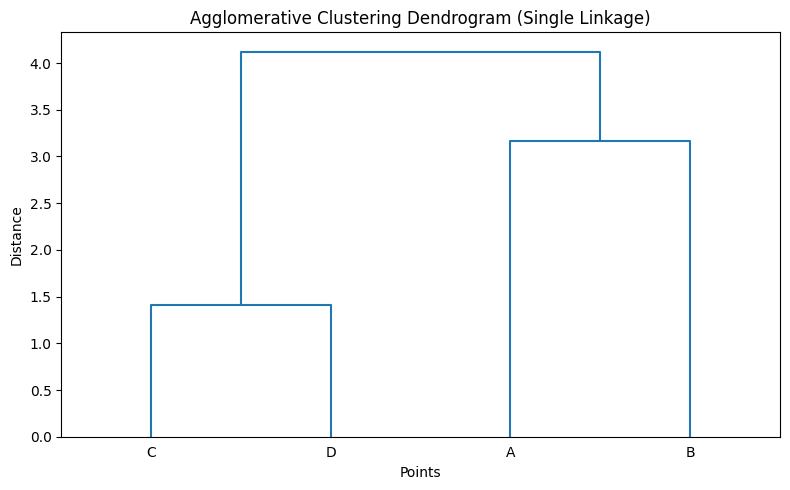


Done.


In [ ]:
# Agglomerative Clustering (Single Linkage) - Step-by-Step with Dendrogram
import numpy as np
from itertools import combinations
from math import sqrt, inf
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# -------------------------
# Dataset
# -------------------------
data = np.array([
    [1, 5],  # A
    [2, 2],  # B
    [6, 3],  # C
    [7, 4]   # D
])

labels = ["A", "B", "C", "D"]

# -------------------------
# Euclidean distance function
# -------------------------
def euclidean(a, b):
    return sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

# -------------------------
# Precompute pairwise distances
# -------------------------
point_dist = {}
for i, j in combinations(range(len(labels)), 2):
    d = euclidean(data[i], data[j])
    point_dist[(labels[i], labels[j])] = d
    point_dist[(labels[j], labels[i])] = d  # symmetric

# -------------------------
# Single linkage cluster distance
# -------------------------
def cluster_distance_single_link(c1, c2):
    best = inf
    for a in c1:
        for b in c2:
            d = point_dist[(a, b)]
            if d < best:
                best = d
    return best

# -------------------------
# Print distance matrix
# -------------------------
def print_distance_matrix(clusters):
    n = len(clusters)
    names = ["(" + ",".join(c) + ")" for c in clusters]
    mat = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            if i == j:
                mat[i, j] = 0.0
            elif i < j:
                mat[i, j] = cluster_distance_single_link(clusters[i], clusters[j])
                mat[j, i] = mat[i, j]
    print("\nDistance matrix (single linkage):")
    print("       " + "  ".join(f"{name:>10}" for name in names))
    for i, name in enumerate(names):
        row = "  ".join(f"{mat[i,j]:10.3f}" for j in range(n))
        print(f"{name:>10}  {row}")
    return mat

# -------------------------
# Agglomerative Clustering Process
# -------------------------
clusters = [[l] for l in labels]
step = 0
linkage_steps = []  # (step, cluster A, cluster B, distance)
merge_history = []  # for scipy dendrogram format

print("Initial Data Points:")
for i, v in enumerate(data):
    print(f" {labels[i]}: {v}")

print("\n=== ITERATIONS ===")
mat = print_distance_matrix(clusters)

while len(clusters) > 1:
    step += 1
    n = len(clusters)
    min_d = inf
    min_pair = (None, None)
    for i in range(n):
        for j in range(i+1, n):
            d = cluster_distance_single_link(clusters[i], clusters[j])
            if d < min_d:
                min_d = d
                min_pair = (i, j)
    i, j = min_pair
    c_i, c_j = clusters[i], clusters[j]
    merged = c_i + c_j

    linkage_steps.append((step, c_i.copy(), c_j.copy(), min_d))

    # Print step details
    print(f"\nStep {step}:")
    print(f" Minimum distance = {min_d:.3f} between clusters ({','.join(c_i)}) and ({','.join(c_j)})")
    print(f" Merging to form cluster: ({','.join(merged)})")

    # Track cluster merge for dendrogram
    merge_history.append((c_i, c_j, min_d, len(merged)))

    # Merge clusters
    new_clusters = []
    for idx, c in enumerate(clusters):
        if idx in (i, j):
            continue
        new_clusters.append(c)
    new_clusters.append(merged)
    clusters = new_clusters

    # Updated matrix
    mat = print_distance_matrix(clusters)

# -------------------------
# Linkage summary table
# -------------------------
print("\n=== LINKAGE SUMMARY ===")
print(f"{'Step':>4}  {'Cluster A':>12}  {'Cluster B':>12}  {'Distance':>8}")
for s, a, b, d in linkage_steps:
    name_a = "(" + ",".join(a) + ")"
    name_b = "(" + ",".join(b) + ")"
    print(f"{s:4d}  {name_a:12}  {name_b:12}  {d:8.3f}")

# -------------------------
# Create scipy-style linkage matrix
# -------------------------
label_to_index = {label: i for i, label in enumerate(labels)}
linkage_matrix = []

def get_index(cluster):
    if len(cluster) == 1:
        return label_to_index[cluster[0]]
    else:
        for idx, (a, b, d, s) in enumerate(merge_history):
            if set(a + b) == set(cluster):
                return len(labels) + idx

for cA, cB, dist, size in merge_history:
    linkage_matrix.append([get_index(cA), get_index(cB), dist, size])

linkage_matrix = np.array(linkage_matrix)

# -------------------------
# Plot dendrogram
# -------------------------
plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=labels, leaf_font_size=10, orientation='top', color_threshold=0.5)
plt.title("Agglomerative Clustering Dendrogram (Single Linkage)")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

print("\nDone.")



# **lab12**
implement KNN.

In [ ]:
import math
from collections import Counter

# === Dataset ===
data = {
    "A": {"battery": 8, "ram": 16, "type": "Gaming"},
    "B": {"battery": 12, "ram": 8, "type": "Ultrabook"},
    "C": {"battery": 6, "ram": 32, "type": "Gaming"},
    "D": {"battery": 15, "ram": 8, "type": "Ultrabook"},
    "E": {"battery": 9, "ram": 4, "type": "Business"},
    "F": {"battery": 14, "ram": 16, "type": "Ultrabook"},
    "G": {"battery": 7, "ram": 8, "type": "Business"},
}

# === New Laptop (Query Point) ===
X = {"battery": 10, "ram": 12}
K = 5

# === Euclidean Distance Function ===
def euclidean(p, q):
    dx = p["battery"] - q["battery"]
    dy = p["ram"] - q["ram"]
    return math.sqrt(dx**2 + dy**2)

# === Display Dataset ===
print("Dataset (ID: battery life, RAM, type):")
for id_, v in data.items():
    print(f" {id_:>1}: ({v['battery']}, {v['ram']}) -> {v['type']}")

print(f"\nQuery laptop X: (battery = {X['battery']} hrs, RAM = {X['ram']} GB)")
print(f"Using K = {K}\n")

# === Step 1: Compute Distances ===
distances = []
print("Step 1: Distance from X to each laptop:\n")
for id_, v in data.items():
    d = euclidean(X, v)
    print(f" {id_:>1}: Distance = {d:.3f} --> {v['type']}")
    distances.append((id_, d, v["type"]))

# === Step 2: Pick K Nearest Neighbors ===
neighbors = sorted(distances, key=lambda x: x[1])[:K]

print(f"\nStep 2: Pick K = {K} nearest neighbors:\n")
for i, (id_, d, res) in enumerate(neighbors, start=1):
    print(f" Neighbor {i}: ID = {id_}, Distance = {d:.3f}, Type = {res}")

# === Step 3: Majority Voting ===
labels = [res for (_, _, res) in neighbors]
votes = Counter(labels)
print("\nStep 3: Voting among neighbors:")
for label, count in votes.items():
    print(f" {label}: {count} vote(s)")

# === Prediction (tie-breaking rule) ===
most_common = votes.most_common()
if len(most_common) == 1:
    predicted = most_common[0][0]
else:
    top_count = most_common[0][1]
    tied = [lbl for lbl, cnt in most_common if cnt == top_count]
    if len(tied) == 1:
        predicted = tied[0]
    else:
        predicted = neighbors[0][2]

# === Step 4: Conclusion ===
print(f"\nFinal Prediction for X (K={K}): {predicted}")
print("\nConclusion:")
print(f"A laptop with 10 hours battery life and 12GB RAM is predicted to be a {predicted.upper()} type laptop.")
print("Reason: Based on the majority class among the 3 nearest neighbors (tie broken by nearest neighbor if needed).")


Dataset (ID: battery life, RAM, type):
 A: (8, 16) -> Gaming
 B: (12, 8) -> Ultrabook
 C: (6, 32) -> Gaming
 D: (15, 8) -> Ultrabook
 E: (9, 4) -> Business
 F: (14, 16) -> Ultrabook
 G: (7, 8) -> Business

Query laptop X: (battery = 10 hrs, RAM = 12 GB)
Using K = 5

Step 1: Distance from X to each laptop:

 A: Distance = 4.472 --> Gaming
 B: Distance = 4.472 --> Ultrabook
 C: Distance = 20.396 --> Gaming
 D: Distance = 6.403 --> Ultrabook
 E: Distance = 8.062 --> Business
 F: Distance = 5.657 --> Ultrabook
 G: Distance = 5.000 --> Business

Step 2: Pick K = 5 nearest neighbors:

 Neighbor 1: ID = A, Distance = 4.472, Type = Gaming
 Neighbor 2: ID = B, Distance = 4.472, Type = Ultrabook
 Neighbor 3: ID = G, Distance = 5.000, Type = Business
 Neighbor 4: ID = F, Distance = 5.657, Type = Ultrabook
 Neighbor 5: ID = D, Distance = 6.403, Type = Ultrabook

Step 3: Voting among neighbors:
 Gaming: 1 vote(s)
 Ultrabook: 3 vote(s)
 Business: 1 vote(s)

Final Prediction for X (K=5): Ultrabook

C